# Logistic Regression with a Binary Outcome 
## Predicting a Student Passing Based on Study Hours

In [2]:
# import the necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

In [3]:
# load the csv to df
df = pd.read_csv('student_pass.csv')

df.head()

,Hours_Studied,Pass
0,6.39,1
1,0.25,0
2,2.23,1
3,6.77,1
4,8.92,1


In [4]:
X = df[["Hours_Studied"]] # 2D
y = df["Pass"]            # 1D

In [5]:
# split the data
# stratify=y preserves class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # learn + apply shorthand
X_test = scaler.transform(X_test)       # apply only

In [7]:
# fit the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
# prediction report
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.80      0.57      0.67         7

    accuracy                           0.60        10
   macro avg       0.60      0.62      0.58        10
weighted avg       0.68      0.60      0.62        10



### Report Interpretation
* In the 10 examples, 7 are in class 1 (pass), and 3 are in class 0 (fail)
* The overall accuracy was 60%, barely above the half percentage.
#### Fail Class Interpretation
* In the "fail" class, the precision is around 40%, it means that when it tries to predict a "fail" outcome, it is wrong at most times
* The recall is 67%. In the 3 test samples more than half was correctly predicted
#### Pass Class Interpretation
* In the "pass" class, the precision is around 80%, it means that when it tries to predict a "pass" outcome it was right at most times.
* The recall is 57%. In the 7 test examples barely more than half was correctly predicted

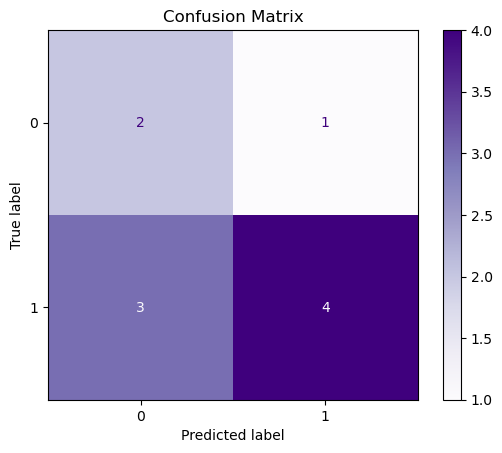

In [9]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Purples")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation
* 4 were predicted to pass and actually passed
* 2 were predicted to fail and actually failed
* 1 was predicted to pass but actually failed
* 3 were predicted to fail but actually passed

The model's overall prediction accuracy was low but also 3 which is the second highest was actually biased to predict fail.

### Sigmoid curve

In [10]:
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_prob = model.predict_proba(X_range)[:, 1] # predict the probabilities

decision_boundary = X_range[np.argmin(np.abs(y_prob - 0.5))][0]

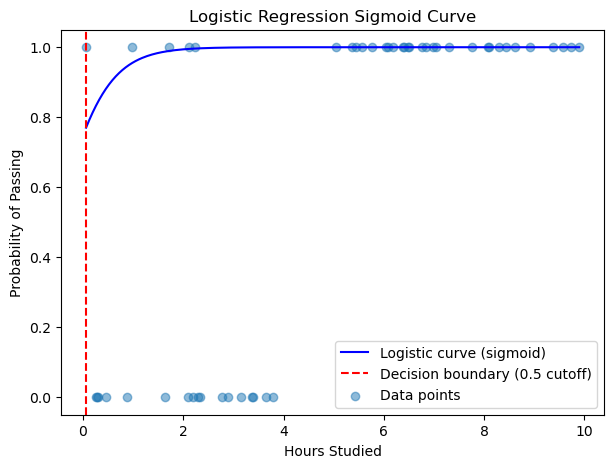

In [11]:
plt.figure(figsize=(7,5))
plt.plot(X_range, y_prob, color="blue", label="Logistic curve (sigmoid)")
plt.axvline(x=decision_boundary, color="red", linestyle="--", label="Decision boundary (0.5 cutoff)")
plt.scatter(X, y, alpha=0.5, label="Data points")
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Sigmoid Curve")
plt.legend()
plt.show()

### Predicting probabilities of passing as study hours increase

In [16]:
beta0 = model.intercept_[0]
beta1 = model.coef_[0][0]

log_odds = beta0 + beta1 * X_range
probabilities = 1 / (1 + np.exp(-log_odds))
odds_ratio = np.exp(beta1)

In [32]:
print("Intercept:", beta0)
print("Coefficient:", beta1)
print("Odds ratio: ", odds_ratio)
# print("Log odds: ", log_odds)
# print("Probabilities: ", probabilities)

Intercept: 1.0885545473549985
Coefficient: 2.006184111339474
Odds ratio:  7.434892426940604


#### Coef Interpretation
* The coefficient is approximately 2. **This means that a student's odds of passing is multiplied by ~7.43 for every study hour increased.**

#### Prediction for a given study hour

In [35]:
study_hour = 2
pred = model.predict([[study_hour]])[0]
prob = model.predict_proba([[study_hour]])[0]

print(f"Study hours: {study_hour}")
print(f"Prediction: {'Pass' if pred == 1 else 'Fail'}")
print(f"P(Fail): {prob[0]:.2%}")
print(f"P(Pass): {prob[1]:.2%}")

Study hours: 2
Prediction: Pass
P(Fail): 0.61%
P(Pass): 99.39%
